# Transformer-Based Summarization — PEGASUS
Abstractive summarization menggunakan `thonyyy/pegasus_indonesian_base-finetune`.

**Objektif:**
1. **Summary quality** — ROUGE-1, ROUGE-2, ROUGE-L
2. **Contextual understanding** — contoh kualitatif
3. **Computational efficiency** — waktu inferensi

Input: `data_final.csv`

---
## Instalasi & Import

In [1]:
!pip install -q "scipy>=1.14" "rouge-score" "transformers==4.44.0" sentencepiece tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 100.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, b

In [2]:
!pip install -q --force-reinstall "scipy>=1.14.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 74.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
ydata-profiling 4.18.4 requires scipy<1.17,>=1.8, but you have scipy 1.18.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incomp

In [3]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from transformers import PegasusTokenizer, PegasusForConditionalGeneration
from rouge_score import rouge_scorer
from tqdm import tqdm
tqdm.pandas()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


---
## Load Dataset

In [4]:
df = pd.read_csv('/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_final.csv', encoding='utf-8-sig')

print(f'Dataset dimuat: {len(df)} baris, {len(df.columns)} kolom')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi kategori:')
print(df['category'].value_counts().to_string())

Dataset dimuat: 12754 baris, 8 kolom
Kolom: ['global_id', 'id', 'title', 'category', 'article_text', 'body_word_count', 'lead_paragraph', 'lead_word_count']

Distribusi kategori:
category
sejarah     1986
arts        1975
artis       1971
kuliner     1958
tech        1728
biografi    1701
sains       1435


---
## 1. Preprocessing Teks

### 1a. Fungsi Pembersihan
**Identik dengan model lain** — hapus noise tanpa mengubah isi kalimat agar ROUGE tetap adil.

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\[\d+\]', '', text)                      # hapus referensi [1], [2]
    text = re.sub(r'={2,}.*?={2,}', '', text)                # hapus == heading ==
    text = re.sub(r'http\S+|www\.\S+', '', text)             # hapus URL
    text = re.sub(r'\{\{.*?\}\}', '', text, flags=re.DOTALL) # hapus {{template}}
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    text = re.sub(r'\s+', ' ', text)                         # rapikan spasi/newline
    text = text.lower() 
    text = re.sub(r"[^a-z0-9\s,.]", "", text) # hapus semua karakter selain huruf, angka, spasi, koma, titik
    return text.strip()

df['clean_text'] = df['article_text'].apply(clean_text)

print('Preprocessing selesai.')
print(f'\nContoh hasil (200 karakter):')
print(df['clean_text'].iloc[0][:200])

Preprocessing selesai.

Contoh hasil (200 karakter):
keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an. pada saat itu sudah ada beberapa penyanyi anakanak seperti fenty effendy, anna mathovani, atau nenny triana. namun yang bisa dibilang


### 1b. Re-filter Artikel Pendek

In [6]:
df['body_word_count'] = df['clean_text'].str.split().str.len()

MIN_WORDS = 100

before = len(df)
df = df[df['body_word_count'] >= MIN_WORDS].reset_index(drop=True)

print(f'Sebelum filter: {before} baris')
print(f'Sesudah filter: {len(df)} baris')
print(f'\nStatistik panjang artikel:')
print(df['body_word_count'].describe().round(0).to_string())

Sebelum filter: 12754 baris
Sesudah filter: 12644 baris

Statistik panjang artikel:
count    12644.0
mean       452.0
std        484.0
min        100.0
25%        182.0
50%        302.0
75%        538.0
max      11947.0


---
## 2. Load Model PEGASUS
`thonyyy/pegasus_indonesian_base-finetune` — PEGASUS yang di-pre-train pada teks Wikipedia Indonesia lalu di-fine-tune pada dataset Indosum, Liputan6, dan XLSum.

> **Catatan:** Model ini tersimpan dalam format TensorFlow, sehingga perlu `from_tf=True` saat load ke PyTorch.

In [7]:
PEGASUS_MODEL_NAME = 'thonyyy/pegasus_indonesian_base-finetune'

print(f'Memuat tokenizer dari {PEGASUS_MODEL_NAME}...')
tokenizer = PegasusTokenizer.from_pretrained(PEGASUS_MODEL_NAME)

print('Memuat model (from_tf=True, mungkin butuh beberapa menit)...')
model = PegasusForConditionalGeneration.from_pretrained(
    PEGASUS_MODEL_NAME,
    from_tf=True
).to(DEVICE)
model.eval()

print(f'Model siap | Parameter: {model.num_parameters():,}')

Memuat tokenizer dari thonyyy/pegasus_indonesian_base-finetune...


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/822k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/764 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/525M [00:00<?, ?B/s]

2026-06-20 10:39:33.823229: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781951974.023212      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781951974.087295      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781951974.605430      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781951974.605469      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781951974.605472      23 computation_placer.cc:177] computation placer alr

generation_config.json:   0%|          | 0.00/170 [00:00<?, ?B/s]

Model siap | Parameter: 130,954,752


---
## 3. Fungsi Summarization

### 3a. Fungsi Generik Summarize

In [8]:
MAX_INPUT_TOKENS  = 512
MAX_OUTPUT_TOKENS = 128
MIN_OUTPUT_TOKENS = 30

def summarize_pegasus(text):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        max_length=MAX_INPUT_TOKENS,
        truncation=True,
        padding=False
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_OUTPUT_TOKENS,
            min_new_tokens=MIN_OUTPUT_TOKENS,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=1.0
        )

    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return summary.strip()

### 3b. Chunking untuk Artikel Panjang
Model transformer punya batasan panjang input (512 token). Artikel yang lebih panjang perlu dipecah dulu.

In [9]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

def split_sentences(text):
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.split()) >= 4]

MAX_SENTENCES_PER_CHUNK = 20

def chunk_sentences(sentences, max_per_chunk=MAX_SENTENCES_PER_CHUNK):
    return [sentences[i:i+max_per_chunk] for i in range(0, len(sentences), max_per_chunk)]

def summarize_with_chunking(text):
    sentences = split_sentences(text)

    if len(sentences) <= MAX_SENTENCES_PER_CHUNK:
        return summarize_pegasus(text)

    chunks = chunk_sentences(sentences)
    chunk_summaries = []
    for chunk in chunks:
        chunk_text = ' '.join(chunk)
        chunk_summaries.append(summarize_pegasus(chunk_text))

    combined = ' '.join(chunk_summaries)
    return summarize_pegasus(combined)

print('=== Demo PEGASUS ===')
print(summarize_with_chunking(df['clean_text'].iloc[0]))

=== Demo PEGASUS ===
kualitas seorang penyanyi cilik umumnya lebih tinggi, karena nilai jual mereka masih keluguan khas. lagu yang terpenting adalah lagu tersebut adalah lagu anakanak mereka sesuai segmen pendengarnya, yakni anakanak ketika tren lawak tunggal mulai menjamur di pertelevisian indonesia


---
## 4. Generate Ringkasan untuk Seluruh Dataset

In [10]:
print('Generating ringkasan PEGASUS...')
start = time.time()

df['summary_pegasus'] = df['clean_text'].progress_apply(summarize_with_chunking)

time_pegasus = time.time() - start
print(f'Selesai dalam {time_pegasus:.1f} detik ({time_pegasus/len(df):.2f} detik/artikel)')
print(f'\nContoh:')
print(f'JUDUL    : {df["title"].iloc[0]}')
print(f'RINGKASAN: {df["summary_pegasus"].iloc[0]}')

Generating ringkasan PEGASUS...


100%|██████████| 12644/12644 [4:49:26<00:00,  1.37s/it]

Selesai dalam 17366.9 detik (1.37 detik/artikel)

Contoh:
JUDUL    : Daftar artis cilik Indonesia
RINGKASAN: kualitas seorang penyanyi cilik umumnya lebih tinggi, karena nilai jual mereka masih keluguan khas. lagu yang terpenting adalah lagu tersebut adalah lagu anakanak mereka sesuai segmen pendengarnya, yakni anakanak ketika tren lawak tunggal mulai menjamur di pertelevisian indonesia


---
## 5. Simpan Hasil

In [11]:
output_cols = ['global_id', 'title', 'category', 'summary_pegasus', 'lead_paragraph', 'body_word_count']
hasil = df[[c for c in output_cols if c in df.columns]]

hasil.to_csv('hasil_summary_pegasus.csv', index=False, encoding='utf-8-sig')
print(f'Tersimpan: hasil_summary_pegasus.csv ({len(hasil)} baris)')

for i in range(min(3, len(hasil))):
    print(f'\n[{hasil["category"].iloc[i]}] {hasil["title"].iloc[i]}')
    print(f'  PEGASUS: {hasil["summary_pegasus"].iloc[i][:120]}...')

Tersimpan: hasil_summary_pegasus.csv (12644 baris)

[artis] Daftar artis cilik Indonesia
  PEGASUS: kualitas seorang penyanyi cilik umumnya lebih tinggi, karena nilai jual mereka masih keluguan khas. lagu yang terpenting...

[artis] A. Sarosa
  PEGASUS: ali sarosa lahir pada tanggal 20 februari 1918 di banyumas, jawa tengah. beliau menyelesaikan pendidikannya di mulo dan ...

[artis] Onadio Leonardo
  PEGASUS: beby prisillia gustiansyahyang kini dikenal sebagai beby leonardo. beby beragama islam dan onadio beragama katolik. mere...


---
## 6. Evaluasi ROUGE
Metrik: ROUGE-1, ROUGE-2, ROUGE-L dengan ground truth `lead_paragraph`.

In [12]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

r1, r2, rl = [], [], []
for pred, ref in zip(df['summary_pegasus'], df['lead_paragraph']):
    s = scorer.score(str(ref), str(pred))
    r1.append(s['rouge1'].fmeasure)
    r2.append(s['rouge2'].fmeasure)
    rl.append(s['rougeL'].fmeasure)

rouge_pegasus = (np.mean(r1), np.mean(r2), np.mean(rl))

print(f'{"Metrik":<10} | {"Skor":>8}')
print('-' * 22)
print(f'{"ROUGE-1":<10} | {rouge_pegasus[0]:>8.4f}')
print(f'{"ROUGE-2":<10} | {rouge_pegasus[1]:>8.4f}')
print(f'{"ROUGE-L":<10} | {rouge_pegasus[2]:>8.4f}')

Metrik     |     Skor
----------------------
ROUGE-1    |   0.1573
ROUGE-2    |   0.0365
ROUGE-L    |   0.1108


### 6a. ROUGE-L per Kategori

In [13]:
rows = []
for kategori in sorted(df['category'].unique()):
    sub = df[df['category'] == kategori]
    scores = [scorer.score(str(ref), str(pred))['rougeL'].fmeasure
              for pred, ref in zip(sub['summary_pegasus'], sub['lead_paragraph'])]
    rows.append({'kategori': kategori, 'jumlah': len(sub), 'rougeL': np.mean(scores)})

tabel = pd.DataFrame(rows).sort_values('rougeL', ascending=False)
print('ROUGE-L per kategori (PEGASUS):')
print(tabel.round(4).to_string(index=False))

ROUGE-L per kategori (PEGASUS):
kategori  jumlah  rougeL
 sejarah    1976  0.1152
biografi    1679  0.1149
 kuliner    1944  0.1132
    tech    1716  0.1118
    arts    1965  0.1078
   artis    1947  0.1073
   sains    1417  0.1042


### 6b. Computational Efficiency

In [14]:
print('Computational Efficiency — PEGASUS:')
print('=' * 45)
print(f'Total waktu   : {time_pegasus:.1f} detik')
print(f'Per artikel   : {time_pegasus/len(df):.2f} detik')
print(f'Jumlah artikel: {len(df)}')
print(f'Parameter     : {model.num_parameters():,}')

Computational Efficiency — PEGASUS:
Total waktu   : 17366.9 detik
Per artikel   : 1.37 detik
Jumlah artikel: 12644
Parameter     : 130,954,752


---
## 7. Visualisasi

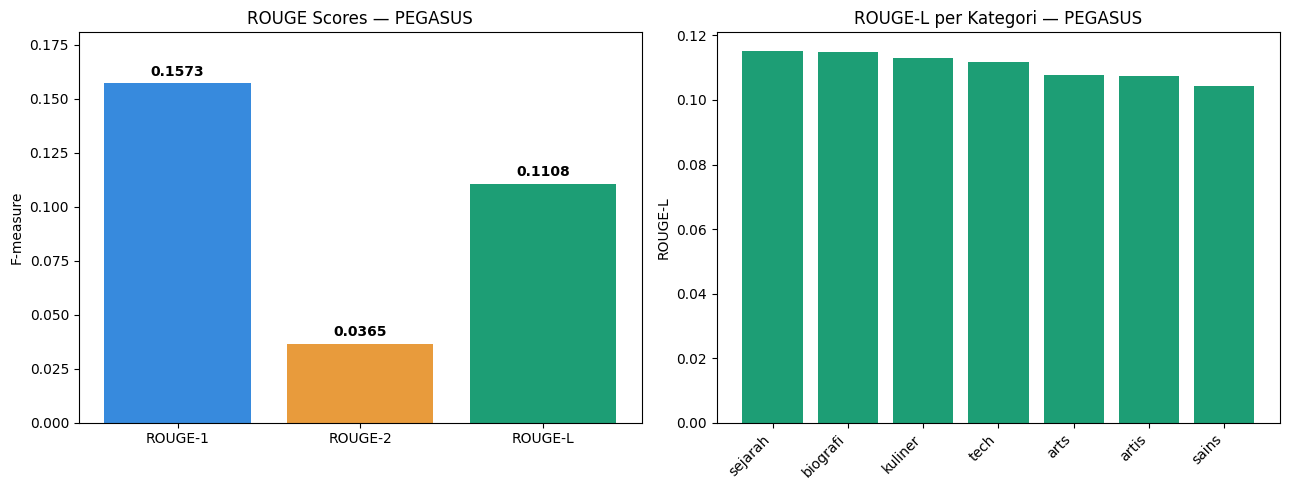

Grafik tersimpan: pegasus_results.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: ROUGE scores
ax = axes[0]
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
vals = list(rouge_pegasus)
bars = ax.bar(metrics, vals, color=['#378ADD', '#E89B3C', '#1D9E75'])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('ROUGE Scores — PEGASUS')
ax.set_ylabel('F-measure')
ax.set_ylim(0, max(vals) * 1.15)

# Plot 2: ROUGE-L per kategori
ax2 = axes[1]
xk = np.arange(len(tabel))
ax2.bar(xk, tabel['rougeL'], color='#1D9E75')
ax2.set_xticks(xk)
ax2.set_xticklabels(tabel['kategori'], rotation=45, ha='right')
ax2.set_title('ROUGE-L per Kategori — PEGASUS')
ax2.set_ylabel('ROUGE-L')

plt.tight_layout()
plt.savefig('pegasus_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan: pegasus_results.png')

---
## 8. Contoh Kualitatif

In [16]:
N_CONTOH = 3
sample_idx = df.sample(N_CONTOH, random_state=42).index

for i, idx in enumerate(sample_idx):
    row = df.loc[idx]
    print(f'{"="*70}')
    print(f'Artikel {i+1}: [{row["category"]}] {row["title"]}')
    print(f'Ground Truth (lead_paragraph):')
    print(f'  {str(row["lead_paragraph"])[:200]}...')
    print(f'PEGASUS:')
    print(f'  {row["summary_pegasus"][:200]}')
    print()

Artikel 1: [biografi] Mardiyanto
Ground Truth (lead_paragraph):
  Mardiyanto (lahir 21 November 1947) adalah politisi dan mantan jenderal Indonesia. Ia menjabat sebagai Gubernur Jawa Tengah mulai tahun 1998, dan terpilih kembali sebagai calon dari partai PDI-P pada ...
PEGASUS:
  kehidupan pendidikan ia mengawali pendidikan di sd kintelan yogyakarta. setelah lulus pada tahun 1958, ia melanjutkan pendidikan di smp bopkri iv yogyakrta dan lulus pada 195

Artikel 2: [arts] Petak umpet
Ground Truth (lead_paragraph):
  Petak umpet adalah sejenis permainan cari dan sembunyi yang bisa dimainkan oleh minimal dua orang yang umumnya dilakukan di luar ruang. Nama permainan ini berbeda-beda di setiap daerah. Petak umpet me...
PEGASUS:
  selain bertujuan untuk bersenang senang, permainan petak umpet juga digunakan sebagai metode pengajaran kemampuan berhitung pada anak dalam tim dengan temannya. beberapa manfaat lain bagi pemain adala

Artikel 3: [kuliner] Industri susu Wisconsin
Ground Truth (lead